In [9]:
import pandas as pd
import optuna
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import shap
import wandb
from Optune_simulation_env import get_best_params, walk_forward_predict_test
from utils import load_data
from scipy.stats import ttest_rel

In [ ]:
N_TRIALS = 30
FINAL_TEST_DAYS = 30
OPTUNA_VAL_DAYS = 30
N_Optuna_Runs = 17
COUNTRY = "HU"

In [ ]:
real_ds = load_data("real", COUNTRY)
synt_ds_lgbm = load_data("lgbm", COUNTRY)
synt_ds_spline = load_data("spline", COUNTRY)
synt_ds_intra = load_data("intra", COUNTRY)

In [12]:
def features():
    STATE_LAGS = [1, 4, 8, 24, 96, 192, 672]   # 15m, 1h, 2h, 6h, 1d, 2d, 1w
    STATE_ROLL_WINS = [24, 96, 672]            # rolling windows on past y (6h, 1d, 1w)
    
    # Feature columns

    STATE_FEATURES = (
        ["last_y"]
        + [f"lag_{L}_t0" for L in STATE_LAGS]
        + ["ramp_1h_t0", "ramp_6h_t0", "ramp_1d_t0"]
        + [f"roll_mean_{w}_t0" for w in STATE_ROLL_WINS]
        + [f"roll_std_{w}_t0" for w in STATE_ROLL_WINS]
    )

    HORIZON_FEATURES = [
        "h", "q_in_hour_target", "qod_target", "hod_target", "dow_target", "month_target", "is_weekend_target",
        "load_fc_target", "load_ramp_1h_target", "load_ramp_6h_target", "renewables_solar_fc","renewables_wind_fc",
        "load_day_mean", "load_day_max", "load_day_min", "q_in_hour_sin", "q_in_hour_cos", "qod_sin", "qod_cos", "hod_sin", "hod_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"
    ]

    WEIGHT_FEATURES = [
        'daily_weight_lag_1d',
        'daily_weight_lag_2d', 'daily_weight_lag_1w', 'hour_weight_lag_1d',
        'hour_weight_lag_2d', 'hour_weight_lag_1w', 'daily_avg_weight_lag_1d',
        'daily_avg_weight_lag_2d', 'daily_avg_weight_lag_1w',
        'hour_avg_weight_lag_1d', 'hour_avg_weight_lag_2d',
        'hour_avg_weight_lag_1w'
    ]

    FEATURE_COLS = STATE_FEATURES + HORIZON_FEATURES + WEIGHT_FEATURES

    return FEATURE_COLS

In [13]:
def run_optuna_once(ds: pd.DataFrame, model: str, synth_type :str, seed: int):
    np.random.seed(seed)
    #wandb.init(project="EnergyPrices_t_test", name=f"{model}_{synth_type}_seed_{seed}", reinit=True)

    FEATURES = features()
    all_days = np.array(sorted(ds["day"].unique()))
    final_test_days = all_days[-FINAL_TEST_DAYS:]
    tune_days = all_days[:-FINAL_TEST_DAYS]

    optuna_val_days = tune_days[-OPTUNA_VAL_DAYS:]
    optuna_train_days_pool = all_days

    study = get_best_params(
        ds=ds,
        train_days_pool=optuna_train_days_pool,
        val_days=optuna_val_days,
        n_trials=N_TRIALS,
        FEATURE_COLS=FEATURES,
        model_type=model,
        seed=seed,  # IMPORTANT if supported
        study_name="HUPX_LightGBM"
    )

    best_params = study.best_params

    test_res = walk_forward_predict_test(
        ds=ds,
        best_params=best_params,
        train_days_pool=optuna_train_days_pool,
        test_days=final_test_days,
        feature_cols=FEATURES,
        model_type=model
    )

    y_true = test_res["y_true"]
    y_pred = test_res["y_pred"]

    rmse = root_mean_squared_error(y_true=y_true, y_pred=y_pred)

    #wandb.log({
    #    "final_mae": test_res["mae"],
    #    "final_rmse": rmse
    #})
    #wandb.finish()


    return {
        "mae": test_res["mae"],
        "rmse": rmse
    }

In [14]:
results_real_rmse = []
results_synth_lgbm_rmse = []
results_synth_spline_rmse = []
results_synth_intra_rmse = []
results_real_mae = []
results_synth_lgbm_mae = []
results_synth_spline_mae = []
results_synth_intra_mae = []


for i in range(N_Optuna_Runs):
    print(f"Run {i}")

    res_real = run_optuna_once(real_ds, "rf", "real", seed=i)
    res_synth_lgbm = run_optuna_once(synt_ds_lgbm, "rf", "lgbm", seed=i)
    res_synth_spline = run_optuna_once(synt_ds_spline, "rf", "spline", seed=i)
    res_synth_intra = run_optuna_once(synt_ds_intra, "rf", "intra", seed=i)

    results_real_rmse.append(res_real["rmse"])
    results_synth_lgbm_rmse.append(res_synth_lgbm["rmse"])
    results_synth_spline_rmse.append(res_synth_spline["rmse"])
    results_synth_intra_rmse.append(res_synth_intra["rmse"])
    
    results_real_mae.append(res_real["mae"])
    results_synth_lgbm_mae.append(res_synth_lgbm["mae"])
    results_synth_spline_mae.append(res_synth_spline["mae"])
    results_synth_intra_mae.append(res_synth_intra["mae"])

[I 2026-03-30 20:08:58,453] A new study created in memory with name: HUPX_LightGBM


Run 0


[I 2026-03-30 20:09:02,481] Trial 0 finished with value: 22.36136279357821 and parameters: {'synth_weight': 0.7314410514212307, 'retrain_every': 8, 'n_estimators': 305, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 13, 'max_features': 'log2'}. Best is trial 0 with value: 22.36136279357821.
[I 2026-03-30 20:09:06,123] Trial 1 finished with value: 22.351340649041504 and parameters: {'synth_weight': 0.652224942398926, 'retrain_every': 8, 'n_estimators': 269, 'max_depth': 19, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 22.351340649041504.
[I 2026-03-30 20:09:12,565] Trial 2 finished with value: 21.67529922808257 and parameters: {'synth_weight': 0.8574691968694659, 'retrain_every': 9, 'n_estimators': 490, 'max_depth': 26, 'min_samples_split': 10, 'min_samples_leaf': 16, 'max_features': 'sqrt'}. Best is trial 2 with value: 21.67529922808257.
[I 2026-03-30 20:09:15,684] Trial 3 finished with value: 22.292494405219138 and

Best overall value: 21.569648064062292
Best overall params: {'synth_weight': 0.7935729227719286, 'retrain_every': 9, 'n_estimators': 493, 'max_depth': 16, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': 'sqrt'}


[I 2026-03-30 20:13:13,311] A new study created in memory with name: HUPX_LightGBM
[I 2026-03-30 20:13:30,767] Trial 0 finished with value: 23.44050193610437 and parameters: {'synth_weight': 0.7314410514212307, 'retrain_every': 8, 'n_estimators': 305, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 13, 'max_features': 'log2'}. Best is trial 0 with value: 23.44050193610437.
[I 2026-03-30 20:13:48,078] Trial 1 finished with value: 24.21121061946565 and parameters: {'synth_weight': 0.652224942398926, 'retrain_every': 8, 'n_estimators': 269, 'max_depth': 19, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 23.44050193610437.
[I 2026-03-30 20:14:23,687] Trial 2 finished with value: 24.730509591085045 and parameters: {'synth_weight': 0.8574691968694659, 'retrain_every': 9, 'n_estimators': 490, 'max_depth': 26, 'min_samples_split': 10, 'min_samples_leaf': 16, 'max_features': 'sqrt'}. Best is trial 0 with value: 23.4405019361043

...

Best overall value: 23.113634768069666
Best overall params: {'synth_weight': 0.5803769562401573, 'retrain_every': 5, 'n_estimators': 69, 'max_depth': 30, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 'log2'}


[I 2026-03-31 22:03:09,471] A new study created in memory with name: HUPX_LightGBM
[I 2026-03-31 22:03:57,535] Trial 0 finished with value: 29.97549139872456 and parameters: {'synth_weight': 0.5836968061026818, 'retrain_every': 6, 'n_estimators': 280, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 29.97549139872456.
[I 2026-03-31 22:04:03,608] Trial 1 finished with value: 24.22037932225629 and parameters: {'synth_weight': 0.9599364871724313, 'retrain_every': 6, 'n_estimators': 48, 'max_depth': 24, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 1 with value: 24.22037932225629.
[I 2026-03-31 22:04:11,057] Trial 2 finished with value: 23.343965318556112 and parameters: {'synth_weight': 0.5803769562401573, 'retrain_every': 5, 'n_estimators': 69, 'max_depth': 30, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 2 with value: 23.343965318556112.
[I 

Best overall value: 22.874877656119008
Best overall params: {'synth_weight': 0.5078040276261491, 'retrain_every': 10, 'n_estimators': 96, 'max_depth': 26, 'min_samples_split': 10, 'min_samples_leaf': 13, 'max_features': 'log2'}


[I 2026-03-31 22:37:09,690] A new study created in memory with name: HUPX_LightGBM
[I 2026-03-31 22:37:49,981] Trial 0 finished with value: 29.913560434196228 and parameters: {'synth_weight': 0.5836968061026818, 'retrain_every': 6, 'n_estimators': 280, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 29.913560434196228.
[I 2026-03-31 22:37:55,394] Trial 1 finished with value: 23.430547845132534 and parameters: {'synth_weight': 0.9599364871724313, 'retrain_every': 6, 'n_estimators': 48, 'max_depth': 24, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 1 with value: 23.430547845132534.
[I 2026-03-31 22:38:01,925] Trial 2 finished with value: 23.17639499860301 and parameters: {'synth_weight': 0.5803769562401573, 'retrain_every': 5, 'n_estimators': 69, 'max_depth': 30, 'min_samples_split': 12, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 2 with value: 23.17639499860301.
[

Best overall value: 22.294132590552103
Best overall params: {'synth_weight': 0.6890326263083347, 'retrain_every': 7, 'n_estimators': 247, 'max_depth': 13, 'min_samples_split': 12, 'min_samples_leaf': 18, 'max_features': 'log2'}


In [16]:
real_rmse = np.array(results_real_rmse)
lgbm_rmse = np.array(results_synth_lgbm_rmse)
spline_rmse = np.array(results_synth_spline_rmse)
intra_rmse = np.array(results_synth_intra_rmse)

real_mae = np.array(results_real_mae)
lgbm_mae = np.array(results_synth_lgbm_mae)
spline_mae = np.array(results_synth_spline_mae)
intra_mae = np.array(results_synth_intra_mae)

#// Save the values
#// RMSE
np.save("outputs/rf_real_rmse.npy", real_rmse)
np.save("outputs/rf_lgbm_rmse.npy", lgbm_rmse)
np.save("outputs/rf_spline_rmse.npy", spline_rmse)
np.save("outputs/rf_intra_rmse.npy", intra_rmse)

#// MAE
np.save("outputs/rf_real_mae.npy", real_mae)
np.save("outputs/rf_lgbm_mae.npy", lgbm_mae)
np.save("outputs/rf_spline_mae.npy", spline_mae)
np.save("outputs/rf_intra_mae.npy", intra_mae)

In [23]:
print(results_real_rmse)
print(results_synth_lgbm_rmse)

[29.135527953229992, 29.585932009865214, 30.019164140959635, 30.564952583763922, 28.901026619015433, 28.100470002379616, 32.036102189180035, 30.458603499190588, 30.62083321570045, 30.183504614438984, 30.439131379470247, 30.724523885060616, 30.86230129818815, 29.233627066452097, 30.351209416837285, 29.950645487436688, 29.581151696370508]
[25.27687270121736, 26.786387423452375, 23.99263288588551, 25.815724168754524, 25.309215842505893, 24.050706833206068, 24.159859098683572, 24.944164766986205, 25.56388288170831, 24.414089585113064, 25.145836917331046, 25.77939147993763, 25.336959319951383, 25.659937439452, 23.63849693674291, 25.86644097948985, 24.070918054282064]


In [17]:
def confidence_interval(diff, alpha=0.05):
    mean = np.mean(diff)
    std = np.std(diff, ddof=1)
    n = len(diff)

    from scipy.stats import t
    t_val = t.ppf(1 - alpha/2, df=n-1)

    margin = t_val * std / np.sqrt(n)
    return mean, mean - margin, mean + margin


def cohens_d(diff):
    return diff.mean() / diff.std(ddof=1)

In [18]:
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

In [19]:
def plot_paper_results(real, methods, metric="RMSE"):
    
    names = list(methods.keys())
    arrays = list(methods.values())

    means = [real.mean()] + [m.mean() for m in arrays]

    # CI computation
    def ci(a):
        m = np.mean(a)
        se = np.std(a, ddof=1) / np.sqrt(len(a))
        ci = 1.96 * se
        return m, ci

    real_m, real_ci = ci(real)

    cis = [real_ci]
    for m in arrays:
        _, c = ci(m)
        cis.append(c)

    labels = ["Real"] + names

    # -----------------------
    # Mean + CI Bar Plot
    # -----------------------
    plt.figure(figsize=(6,4))

    x = np.arange(len(means))

    plt.bar(x, means, yerr=cis, capsize=5)

    plt.xticks(x, labels)
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison (Mean ±95% CI)")

    plt.tight_layout()
    plt.show()

    # -----------------------
    # Improvement Plot
    # -----------------------
    diffs = [m - real for m in arrays]

    plt.figure(figsize=(6,4))

    plt.boxplot(diffs)

    plt.axhline(0, linestyle="--")

    plt.xticks(range(1, len(names)+1), names)

    plt.ylabel(f"{metric} Difference vs Real")

    plt.title(f"Paired {metric} Improvements")

    plt.tight_layout()
    plt.show()

In [20]:
def evaluate_metric(metric="rmse", plot=True):
    """
    metric: 'rmse' or 'mae'
    """

    # Select correct arrays
    if metric == "rmse":
        real = np.array(results_real_rmse)
        lgbm = np.array(results_synth_lgbm_rmse)
        spline = np.array(results_synth_spline_rmse)
        intra = np.array(results_synth_intra_rmse)
    elif metric == "mae":
        real = np.array(results_real_mae)
        lgbm = np.array(results_synth_lgbm_mae)
        spline = np.array(results_synth_spline_mae)
        intra = np.array(results_synth_intra_mae)
    else:
        raise ValueError("metric must be 'rmse' or 'mae'")

    methods = {
        "Synth LGBM": lgbm,
        "Spline": spline,
        "Intra": intra
    }

    rows = []

    for name, method in methods.items():
        diff = method - real

        mean_metric = method.mean()
        mean_diff, ci_low, ci_high = confidence_interval(diff)
        stat, p = ttest_rel(method, real)
        d = cohens_d(diff)

        rows.append({
            "method": name,
            f"{metric}_mean": mean_metric,
            "diff_mean": mean_diff,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": p,
            "effect_size_d": d
        })

    df = pd.DataFrame(rows)

    # Multiple testing correction
    reject, pvals_corrected, _, _ = multipletests(df["p_value"], method='holm')
    df["p_corrected"] = pvals_corrected
    df["significant"] = reject

    # Improvement %
    df["improvement_%"] = 100 * (-df["diff_mean"] / real.mean())

    # Pretty display
    df_display = df.copy()
    df_display[f"{metric}_mean"] = df_display[f"{metric}_mean"].round(4)
    df_display["diff_mean"] = df_display["diff_mean"].round(4)
    df_display["ci_low"] = df_display["ci_low"].round(4)
    df_display["ci_high"] = df_display["ci_high"].round(4)
    df_display["p_value"] = df_display["p_value"].apply(lambda x: f"{x:.2e}")
    df_display["p_corrected"] = df_display["p_corrected"].apply(lambda x: f"{x:.2e}")
    df_display["effect_size_d"] = df_display["effect_size_d"].round(3)
    df_display["improvement_%"] = df_display["improvement_%"].round(2)

    print(f"\n===== {metric.upper()} RESULTS =====")
    display(df_display)

    # ----------------
    # Plots
    # ----------------
    if plot:
        plot_paper_results(
        real,
        methods,
        metric=metric.upper()
    )

    return df


===== RMSE RESULTS =====


,method,rmse_mean,diff_mean,ci_low,ci_high,p_value,effect_size_d,p_corrected,significant,improvement_%
0,Synth LGBM,25.0477,-4.9963,-5.6481,-4.3445,2.29e-11,-3.941,2.90e-11,True,16.63
1,Spline,24.8485,-5.1955,-5.8533,-4.5377,1.45e-11,-4.061,2.90e-11,True,17.29
2,Intra,24.9312,-5.1128,-5.5263,-4.6993,1.43e-14,-6.357,4.28e-14,True,17.02


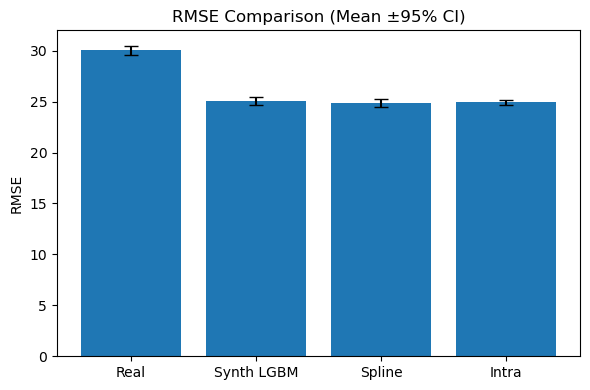

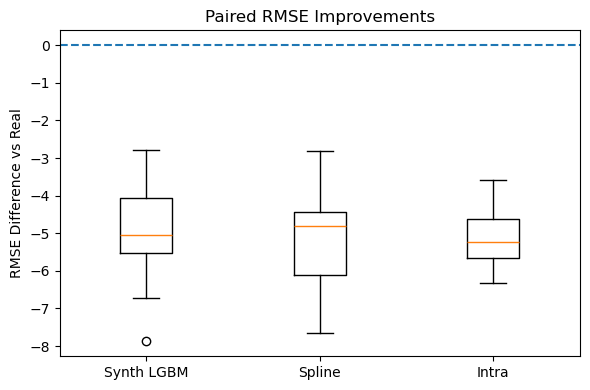

In [21]:
df_rmse = evaluate_metric("rmse")


===== MAE RESULTS =====


,method,mae_mean,diff_mean,ci_low,ci_high,p_value,effect_size_d,p_corrected,significant,improvement_%
0,Synth LGBM,18.1394,-3.4443,-3.8878,-3.0007,1.88e-11,-3.993,2.94e-11,True,15.96
1,Spline,18.0136,-3.5701,-4.0224,-3.1178,1.47e-11,-4.058,2.94e-11,True,16.54
2,Intra,18.1594,-3.4243,-3.6830,-3.1656,4.90e-15,-6.806,1.47e-14,True,15.87


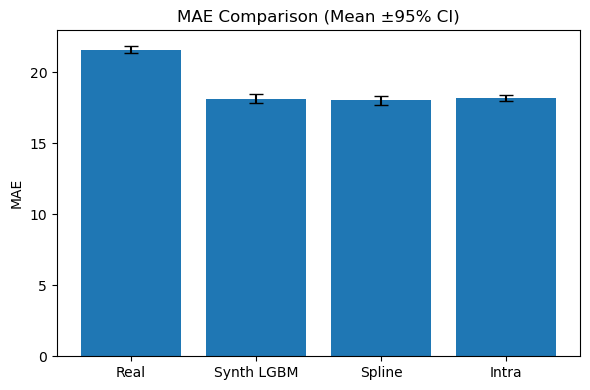

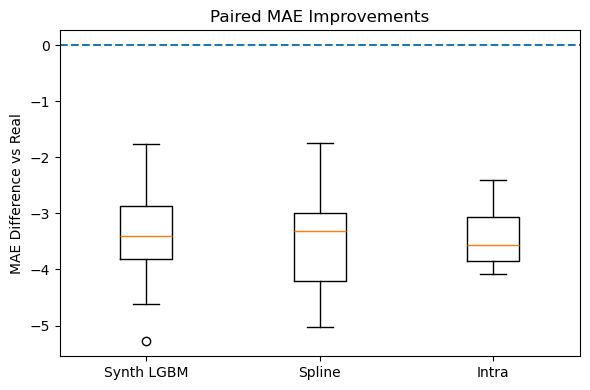

In [22]:
df_mae = evaluate_metric("mae")